# Final Project Group 8
CIS 2100.03


**Check List In Order of Completion**

*When completed write "-Complete" at the end of the task on this list
(ie. clean data -Complete)*


0. Load the CSV -Complete
1.   Print shape, columns, dtpes, head() -Complete
2. Show missing values per column and %missing -Complete
3. Clean column names(strip, snake_case) -Complete
4. Strip whitespace in string columns -Complete
5. Convert dtypes: numeric, datetime, category(with code) - complete
6. Re-run describe() to show it now works for numerics  - complete
7. Handle NaN: explan your choice (drop vs fill)   !! We're going to fill the NaN with 0  - complete
8. Check duplicates and remove if needed  - complete
9. Add at least on sanity check with assert  - complete
10. Save clean_data.csv  - complete
11. Brief relection: 2-3 bullets on what you changed and why.  - complete








DataSet from kaggle


**What question does this data help answer?**

"How many points does a play contribute every 10 minutes of play time?"

*This can help coaches decide who to invest more playing time in*

**What columns will you use for analysis?**
Columns used:
- player
- team
- position
- gp__games_played
- gs__games_started
- mpg_minutes_per_game
- ppg_points_per_game
- points_per_10_minutes

**What visualizations make sense?**
A bar chart and box plot will represent the data the most clearly

**Who will handle what parts (Define Roles in Group)?**

Stefani Wilson Completed: 0-5 in the Check List

Argel Perex Completed: 6-11 in the Check List


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#stefani wilson
# Load the CSV
import pandas as pd


files = [
    '/content/drive/MyDrive/scoring.csv',
    '/content/drive/MyDrive/assists-turnovers.csv',
    '/content/drive/MyDrive/blocks.csv',
    '/content/drive/MyDrive/steals.csv',
    '/content/drive/MyDrive/rebounds.csv',
    '/content/drive/MyDrive/fouls-minutes.csv'
]



common_columns = [
    'Unnamed: 0',
    'Player',
    'Team',
    'Position',
    'GP  Games played',
    'GS  Games started'
]


df_final = pd.read_csv(files[0])

for file in files[1:]:
    df_temp = pd.read_csv(file)


    overlap_cols = [col for col in df_temp.columns if col in df_final.columns]


    cols_to_drop_from_df_temp = [col for col in overlap_cols if col not in common_columns]

    if cols_to_drop_from_df_temp:
        df_temp = df_temp.drop(columns=cols_to_drop_from_df_temp)

    df_final = pd.merge(df_final, df_temp, on=common_columns, how='outer')

df_final.head()


,Unnamed: 0,GP Games played,GS Games started,MPG Minutes Per Game,PPG Points Per Game,FGM Field Goals Made,FGA Field Goals Attempted,FG% Field Goal Percentage,3FGM Three-Point Field Goals Made,3FGA Three-Point Field Goals Attempted,...,STL Total Steals,SPG Steals Per Game,BLK Total Blocks,BPG Blocks Per Game,PF Total Personal Fouls,PFG Personal Fouls Per Game,FLG Flagrant Fouls,TF Technical Fouls,EJ Ejections,DSQ Disqualifications
0,0,21,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,0.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,16,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,19,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,17,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,19,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
#Stefani Wilson
#Print shape, columns, dtypes, head()
print("Dataframe Shape:", df_final.shape)

print("\nColumn Names:", df_final.columns.tolist())

print("\nData Types:\n", df_final.dtypes)

df_final.head()

Dataframe Shape: (1628, 36)

Column Names: ['Unnamed: 0', 'GP  Games played', 'GS  Games started', 'MPG  Minutes Per Game', 'PPG  Points Per Game', 'FGM  Field Goals Made', 'FGA  Field Goals Attempted', 'FG%  Field Goal Percentage', '3FGM  Three-Point Field Goals Made', '3FGA  Three-Point Field Goals Attempted', '3FG%  Three-Point Field Goal Percentage', 'FTM  Free Throws Made', 'FTA  Free Throws Attempted', 'FT%  Free Throw Percentage', 'Player', 'Position', 'Team', 'OREB  Offensive Rebounds', 'DREB  Defensive Rebounds', 'REB  Total Rebounds', 'RPG  Rebounds Per Game', 'AST  Total Assists', 'APG  Assists Per Game', 'TO  Turnovers', 'TOPG  Turnovers Per Game', 'A/TO  Assists Per Turnover', 'STL  Total Steals', 'SPG  Steals Per Game', 'BLK  Total Blocks', 'BPG  Blocks Per Game', 'PF  Total Personal Fouls', 'PFG  Personal Fouls Per Game', 'FLG  Flagrant Fouls', 'TF  Technical Fouls', 'EJ  Ejections', 'DSQ  Disqualifications']

Data Types:
 Unnamed: 0                                   int

,Unnamed: 0,GP Games played,GS Games started,MPG Minutes Per Game,PPG Points Per Game,FGM Field Goals Made,FGA Field Goals Attempted,FG% Field Goal Percentage,3FGM Three-Point Field Goals Made,3FGA Three-Point Field Goals Attempted,...,STL Total Steals,SPG Steals Per Game,BLK Total Blocks,BPG Blocks Per Game,PF Total Personal Fouls,PFG Personal Fouls Per Game,FLG Flagrant Fouls,TF Technical Fouls,EJ Ejections,DSQ Disqualifications
0,0,21,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,0.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,16,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,19,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,17,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,19,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#Stefani Wilson
#Show missing values per column and %missing

missing_count = df_final.isnull().sum()

missing_percent = (df_final.isnull().sum() / len(df_final)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing_count,
    'Percent Missing (%)': missing_percent
})

print(missing_table.sort_values(by='Missing Values', ascending=False))

                                         Missing Values  Percent Missing (%)
RPG  Rebounds Per Game                             1599            98.218673
DREB  Defensive Rebounds                           1599            98.218673
OREB  Offensive Rebounds                           1599            98.218673
REB  Total Rebounds                                1599            98.218673
SPG  Steals Per Game                               1599            98.218673
STL  Total Steals                                  1599            98.218673
PF  Total Personal Fouls                           1378            84.643735
MPG  Minutes Per Game                              1378            84.643735
BLK  Total Blocks                                  1378            84.643735
BPG  Blocks Per Game                               1378            84.643735
3FGM  Three-Point Field Goals Made                 1378            84.643735
PPG  Points Per Game                               1378            84.643735

In [5]:
#Stefani Wilson
#Clean column names(strip, snake_case)

df_final.columns = [col.lower().strip().replace('  ', ' ').replace(' ', '_') for col in df_final.columns]

print("Cleaned Column Names:")
print(df_final.columns.tolist())

Cleaned Column Names:
['unnamed:_0', 'gp_games_played', 'gs_games_started', 'mpg_minutes_per_game', 'ppg_points_per_game', 'fgm_field_goals_made', 'fga_field_goals_attempted', 'fg%_field_goal_percentage', '3fgm_three-point_field_goals_made', '3fga_three-point_field_goals_attempted', '3fg%_three-point_field_goal_percentage', 'ftm_free_throws_made', 'fta_free_throws_attempted', 'ft%_free_throw_percentage', 'player', 'position', 'team', 'oreb_offensive_rebounds', 'dreb_defensive_rebounds', 'reb_total_rebounds', 'rpg_rebounds_per_game', 'ast_total_assists', 'apg_assists_per_game', 'to_turnovers', 'topg_turnovers_per_game', 'a/to_assists_per_turnover', 'stl_total_steals', 'spg_steals_per_game', 'blk_total_blocks', 'bpg_blocks_per_game', 'pf_total_personal_fouls', 'pfg_personal_fouls_per_game', 'flg_flagrant_fouls', 'tf_technical_fouls', 'ej_ejections', 'dsq_disqualifications']


In [6]:
#Stefani Wilson
#Strip Whitespace in String Columns

string_cols = df_final.select_dtypes(include=['object']).columns

for col in string_cols:
    df_final[col] = df_final[col].str.strip()

print("Whitespace stripped from columns:", string_cols.tolist())

df_final[string_cols].head()

Whitespace stripped from columns: ['3fg%_three-point_field_goal_percentage', 'ft%_free_throw_percentage', 'player', 'position', 'team']


,3fg%_three-point_field_goal_percentage,ft%_free_throw_percentage,player,position,team
0,NaN,NaN,Cedi Osman,SF,CLE
1,NaN,NaN,Chris Boucher,C,TOR
2,NaN,NaN,Danuel House Jr.,SF,PHI
3,NaN,NaN,Dillon Brooks,SF,MEM
4,NaN,NaN,George Hill,PG,MIL


In [7]:
#Stefani Wilson
#Convert dtypes: numeric, datetime, category(with code)

cols_to_fix = ['3fg%_three-point_field_goal_percentage', 'ft%_free_throw_percentage']

for col in cols_to_fix:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

df_final['position'] = df_final['position'].astype('category')
df_final['team'] = df_final['team'].astype('category')

print("Updated Data Types:")
print(df_final[['3fg%_three-point_field_goal_percentage', 'ft%_free_throw_percentage', 'position', 'team']].dtypes)

Updated Data Types:
3fg%_three-point_field_goal_percentage     float64
ft%_free_throw_percentage                  float64
position                                  category
team                                      category
dtype: object


In [8]:
#Argel Perez
#Re-run describe() to show it now works for numerics
df_final.describe()


,unnamed:_0,gp_games_played,gs_games_started,mpg_minutes_per_game,ppg_points_per_game,fgm_field_goals_made,fga_field_goals_attempted,fg%_field_goal_percentage,3fgm_three-point_field_goals_made,3fga_three-point_field_goals_attempted,...,stl_total_steals,spg_steals_per_game,blk_total_blocks,bpg_blocks_per_game,pf_total_personal_fouls,pfg_personal_fouls_per_game,flg_flagrant_fouls,tf_technical_fouls,ej_ejections,dsq_disqualifications
count,1628.000000,1628.000000,1628.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,...,29.000000,29.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.00000
mean,137.096437,18.387592,10.266585,25.725600,12.447600,85.856000,181.448000,47.948400,24.956000,69.292000,...,3.344828,0.189655,10.420000,0.556440,39.696000,2.280800,0.160000,0.868000,0.040000,0.25200
std,79.560740,2.609664,8.374688,7.186236,6.462485,44.427045,92.580928,8.046932,17.966336,46.296915,...,1.446075,0.073411,8.501098,0.442489,15.692182,0.674873,0.398793,1.249328,0.196352,0.67996
min,0.000000,2.000000,0.000000,8.100000,4.800000,22.000000,44.000000,29.100000,0.000000,0.000000,...,0.000000,0.000000,2.000000,0.120000,5.000000,0.600000,0.000000,0.000000,0.000000,0.00000
25%,68.000000,17.000000,1.000000,20.025000,7.400000,51.250000,108.250000,42.325000,11.250000,36.000000,...,2.000000,0.130000,5.000000,0.250000,29.000000,1.800000,0.000000,0.000000,0.000000,0.00000
50%,137.000000,19.000000,10.500000,26.750000,10.600000,74.000000,159.000000,46.950000,23.000000,63.000000,...,4.000000,0.200000,8.000000,0.440000,40.000000,2.200000,0.000000,0.000000,0.000000,0.00000
75%,205.000000,20.000000,19.000000,31.900000,16.175000,113.000000,239.500000,52.300000,36.000000,96.750000,...,4.000000,0.250000,14.000000,0.720000,50.000000,2.700000,0.000000,1.000000,0.000000,0.00000
max,278.000000,23.000000,23.000000,37.400000,33.500000,233.000000,434.000000,76.000000,103.000000,236.000000,...,6.000000,0.290000,55.000000,2.890000,92.000000,5.000000,2.000000,8.000000,1.000000,4.00000


In [9]:
import pandas as pd

#Argel Perez
#Handle NaN: fill missing values with 0

print("Missing values before filling NaN:")
print(df_final.isnull().sum().sort_values(ascending=False))

numeric_cols = df_final.select_dtypes(include=['number']).columns

df_final[numeric_cols] = df_final[numeric_cols].fillna(0)

print("\nMissing values after filling NaN:")
print(df_final.isnull().sum().sort_values(ascending=False))

Missing values before filling NaN:
rpg_rebounds_per_game                     1599
dreb_defensive_rebounds                   1599
oreb_offensive_rebounds                   1599
reb_total_rebounds                        1599
spg_steals_per_game                       1599
stl_total_steals                          1599
3fg%_three-point_field_goal_percentage    1388
ft%_free_throw_percentage                 1379
blk_total_blocks                          1378
bpg_blocks_per_game                       1378
pf_total_personal_fouls                   1378
mpg_minutes_per_game                      1378
ftm_free_throws_made                      1378
3fga_three-point_field_goals_attempted    1378
3fgm_three-point_field_goals_made         1378
fg%_field_goal_percentage                 1378
fta_free_throws_attempted                 1378
ppg_points_per_game                       1378
fga_field_goals_attempted                 1378
fgm_field_goals_made                      1378
flg_flagrant_fouls       

We chose to fill missing values with 0 instead of dropping rows because many of the missing values are basketball statistics. If a player was missing a stat from one of the CSV files, we treated it as 0 so we could keep the player in the dataset.

In [10]:
#Argel Perez
#Check duplicates and remove if needed

duplicate_count = df_final.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df_final = df_final.drop_duplicates()
    print("Duplicate rows were removed.")
else:
    print("No duplicate rows found.")

print("Updated dataframe shape:", df_final.shape)

Number of duplicate rows: 0
No duplicate rows found.
Updated dataframe shape: (1628, 36)


In [11]:
#Argel Perez
#Add at least one sanity check with assert

assert df_final.isnull().sum().sum() == 0, "There are still missing values in the dataframe."
assert df_final.shape[0] > 0, "The dataframe has no rows."
assert df_final.shape[1] > 0, "The dataframe has no columns."

print("All sanity checks passed.")


All sanity checks passed.


In [12]:
#Argel Perez
#Save clean_data.csv

df_final.to_csv('/content/drive/MyDrive/clean_data.csv', index=False)

print("Clean data saved as clean_data.csv")

Clean data saved as clean_data.csv


#Argel Perez
#Brief reflection: 2-3 bullets on what you changed and why

- We cleaned the column names by making them lowercase, removing extra spaces, and using snake_case so the columns are easier to use in Python.
- We converted percentage columns from object data types into numeric data types so they could be used in calculations.
- We filled missing values with 0 instead of dropping rows because we wanted to keep all players in the dataset for analysis.

In [13]:
#Argel Perez
#Clean column names again after loading the data

df_final.columns = (
    df_final.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
    .str.replace('-', '_', regex=False)
    .str.replace('%', 'percent', regex=False)
)

df_final.head()

,unnamed:_0,gp_games_played,gs_games_started,mpg_minutes_per_game,ppg_points_per_game,fgm_field_goals_made,fga_field_goals_attempted,fgpercent_field_goal_percentage,3fgm_three_point_field_goals_made,3fga_three_point_field_goals_attempted,...,stl_total_steals,spg_steals_per_game,blk_total_blocks,bpg_blocks_per_game,pf_total_personal_fouls,pfg_personal_fouls_per_game,flg_flagrant_fouls,tf_technical_fouls,ej_ejections,dsq_disqualifications
0,0,21,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,0.29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,16,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,19,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,17,17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,19,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
#Check column names for points and minutes

[col for col in df_final.columns if 'ppg' in col.lower() or 'mpg' in col.lower()]

['mpg_minutes_per_game', 'ppg_points_per_game']

In [15]:
#Argel Perez
#Create points_per_10_minutes column

import numpy as np

df_final['points_per_10_minutes'] = (df_final['ppg_points_per_game'] / df_final['mpg_minutes_per_game']) * 10

df_final['points_per_10_minutes'] = df_final['points_per_10_minutes'].replace([np.inf, -np.inf], 0)
df_final['points_per_10_minutes'] = df_final['points_per_10_minutes'].fillna(0)

df_final[['player', 'team', 'position', 'mpg_minutes_per_game', 'ppg_points_per_game', 'points_per_10_minutes']].head()

,player,team,position,mpg_minutes_per_game,ppg_points_per_game,points_per_10_minutes
0,Cedi Osman,CLE,SF,0.0,0.0,0.0
1,Chris Boucher,TOR,C,0.0,0.0,0.0
2,Danuel House Jr.,PHI,SF,0.0,0.0,0.0
3,Dillon Brooks,MEM,SF,0.0,0.0,0.0
4,George Hill,MIL,PG,0.0,0.0,0.0


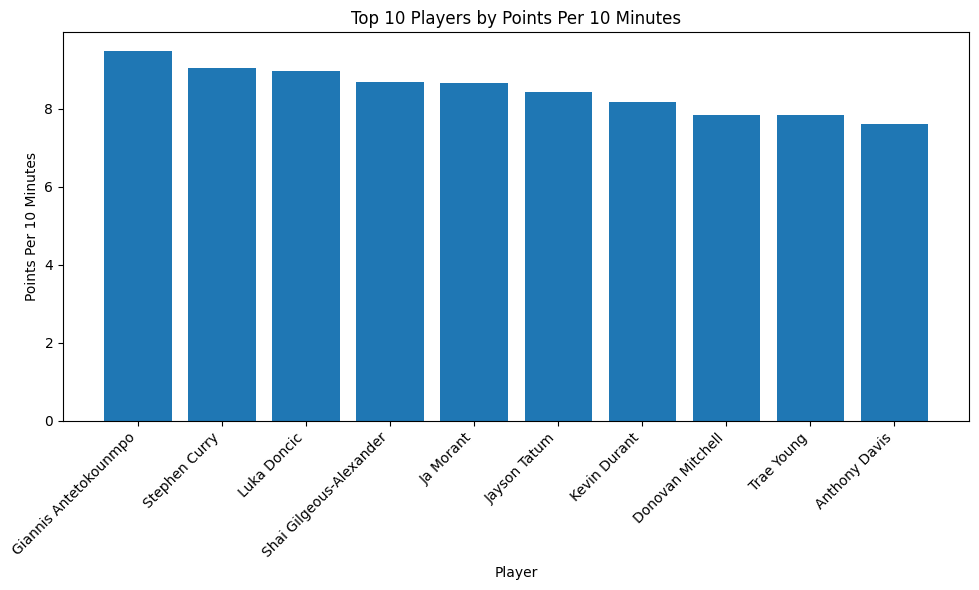

In [16]:
#Argel perez
#Matplotlib bar chart: Top 10 players by points per 10 minutes

import matplotlib.pyplot as plt

top_10_players = df_final.sort_values(by='points_per_10_minutes', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_10_players['player'], top_10_players['points_per_10_minutes'])
plt.title('Top 10 Players by Points Per 10 Minutes')
plt.xlabel('Player')
plt.ylabel('Points Per 10 Minutes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

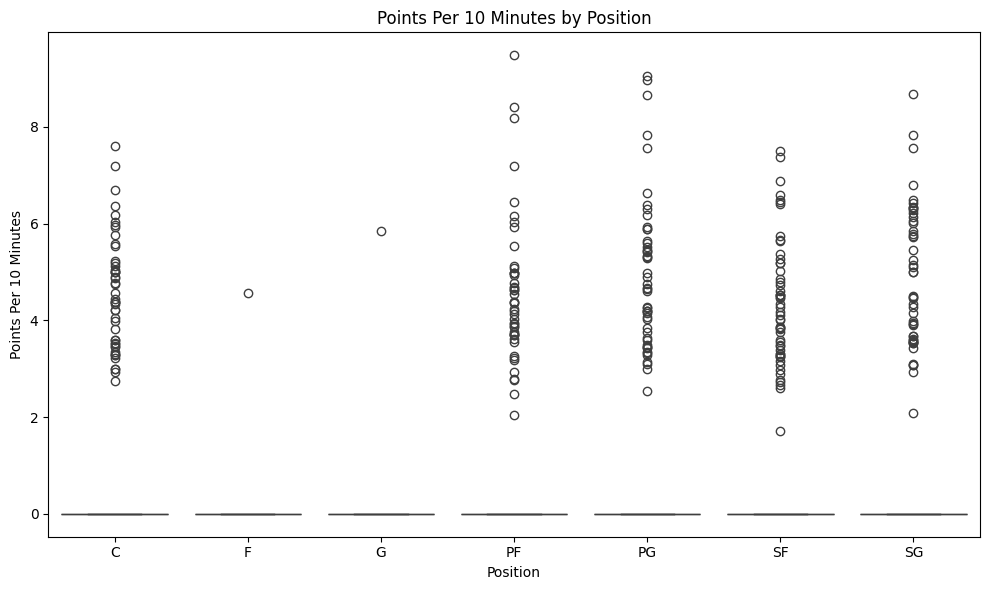

In [17]:
#Argel Perez
#Seaborn boxplot: Points per 10 minutes by position

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x='position', y='points_per_10_minutes')

plt.title('Points Per 10 Minutes by Position')
plt.xlabel('Position')
plt.ylabel('Points Per 10 Minutes')
plt.tight_layout()
plt.show()